In [1]:
import collections
import math
import torch
from networkx.algorithms.shortest_paths import unweighted
from torch import nn
from d2l import torch as d2l

#实现循环神经网络编码器
class Seq2SeqEncoder(d2l.Encoder):
    '''用于序列到序列学习的循环神经网络编码器'''
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0, **kwargs):
        super(Seq2SeqEncoder, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers, dropout = dropout)

    def forward(self, X, *args):
        X = self.embedding(X)
        X = X.permute(1, 0, 2)
        output, state = self.rnn(X)
        return output, state

In [2]:
#上述编码器的实现

encoder = Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)
#编码器切换到评估模式
encoder.eval()
#创建虚拟输入
X = torch.zeros((4,7), dtype=torch.long)
#前向传播
output, state = encoder(X)
print(output.shape)
print(state.shape)

torch.Size([7, 4, 16])
torch.Size([2, 4, 16])


In [3]:
#解码器
class Seq2SeqDecoder(d2l.Decoder):
    '''用于序列到序列学习的循环神经网络解码器'''
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0, **kwargs):
        super(Seq2SeqDecoder, self).__init__(**kwargs)
        #词嵌入层
        self.embedding = nn.Embedding(vocab_size, embed_size)
        #GRU层
        self.rnn = nn.GRU(embed_size+num_hiddens, num_hiddens, num_layers, dropout = dropout)
        #输出层
        self.dense = nn.Linear(num_hiddens, vocab_size)

    ##初始化解码器状态
    def init_state(self, enc_outputs, *args):
        #返回编码器的最终隐藏状态作为解码器的初始隐藏状态（编码器的forward输出为(output, state)的元组）
        return enc_outputs[1]

    #前向传播
    def forward(self, X, state):
        #词嵌入+维度调整
        X = self.embedding(X).permute(1, 0, 2)
        #上下文向量（取state最后一层内容沿着第0维重复seq_len次）
        context = state[-1].repeat(X.shape[0], 1, 1)
        #拼接输入（当前时间步的嵌入向量与重复的上下文向量在最后一维（特征维）拼接）
        X_and_context = torch.cat((X, context), 2)
        #GRU前向
        output, state = self.rnn(X_and_context, state)
        #输出映射与转置
        output = self.dense(output).permute(1, 0, 2)
        return output, state

In [4]:
#实例化解码器
decoder = Seq2SeqDecoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)
decoder.eval()
state = decoder.init_state(encoder(X))
output, state = decoder(X, state)
print(output.shape)
print(state.shape)

torch.Size([4, 7, 10])
torch.Size([2, 4, 16])


In [5]:
#通过零值化屏蔽不相关的项
def sequence_mask(X, valid_len, value=0):
    '''在序列中屏蔽不相关的项'''
    #获取最大长度（X的第二个维度大小）
    maxlen = X.size(1)
    #构造掩码向量
    mask = torch.arange(
        (maxlen), dtype=torch.float32, device=X.device)[None, :] < valid_len[:, None]
    #替换无效位置的值
    X[~mask] = value
    return X

X = torch.tensor([[1,2,3],
                  [4,5,6]])
print(sequence_mask(X, torch.tensor([1,2])))

tensor([[1, 0, 0],
        [4, 5, 0]])


In [6]:
#通过扩展softmax交叉熵损失函数来遮蔽不相关的预测
class MaskedSoftmaxCEloss(nn.CrossEntropyLoss):
    '''带遮蔽的softmax交叉熵损失函数'''
    def forward(self, pred, label, valid_len):
        #构造权重掩码
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valid_len)
        #修改reduction模式，防止默认损失求平均
        self.reduction = 'none'
        #计算未加权的损失（调用父类的前向传播方法）
        unweighted_loss = super().forward(pred.permute(0, 2, 1), label)
        #加权平均
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

In [7]:
#代码健全性检查
loss = MaskedSoftmaxCEloss()
print(loss(torch.ones(3, 4, 10), torch.ones((3, 4), dtype=torch.long), torch.tensor([4, 2, 0])))

tensor([2.3026, 1.1513, 0.0000])


In [8]:
#训练
def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    '''训练序列到序列模型'''
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if 'weight' in param:
                    nn.init.xavier_uniform_(m._parameters[param])

    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCEloss()
    net.train()
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[10,num_epochs])
    for epoch in range(num_epochs):
        timer = d2l.Timer()
        metric = d2l.Accumulator(2)
        for batch in data_iter:
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']]*Y.shape[0],device=device).reshape(-1,1)
            dec_input = torch.cat([bos, Y[:, :-1]], 1)
            Y_hat = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()
            d2l.grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)
        if (epoch + 1) % 10 == 0:
            animator.add(epoch+1, (metric[0]/metric[1],))
    print(f'loss {metric[0]/metric[1]:.3f}, {metric[1]/timer.stop():.3f}'
          f'tokens/sec on {str(device)}')


loss 0.020, 27041.145tokens/sec on cuda:0
None


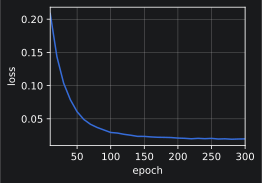

In [9]:
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs, device = 0.005, 300, d2l.try_gpu()

train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)
encoder = Seq2SeqEncoder(len(src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqDecoder(len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
net = d2l.EncoderDecoder(encoder, decoder)
print(train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device))

In [10]:
#预测
def predict_seq2seq(net,src_sentence,  src_vocab, tgt_vocab, num_steps, device, save_attention_weights=False):
    '''序列到序列模型的预测'''
    net.eval()
    src_tokens = src_vocab[src_sentence.lower().split(' ')] + [src_vocab['<eos>']]
    enc_valid_len = torch.tensor([len(src_tokens)], device=device)
    src_tokens = d2l.truncate_pad(src_tokens, num_steps, src_vocab['<pad>'])
    enc_X = torch.unsqueeze(
        torch.tensor(src_tokens, dtype=torch.long, device=device), dim=0
    )
    enc_outputs = net.encoder(enc_X, enc_valid_len)
    dec_state = net.decoder.init_state(enc_outputs, enc_valid_len)
    dec_X = torch.unsqueeze(
        torch.tensor([tgt_vocab['<bos>']], dtype=torch.long, device=device), dim=0
    )
    output_seq, attention_weight_seq = [], []
    for _ in range(num_steps):
        Y, dec_state = net.decoder(dec_X, dec_state)
        dec_X = Y.argmax(dim=2)
        pred = dec_X.squeeze(dim=0).type(torch.int32).item()
        if save_attention_weights:
            attention_weight_seq.append(net.decoder.attention_weights)
        if pred == tgt_vocab['<eos>']:
            break
        output_seq.append(pred)
    return ' '.join(tgt_vocab.to_tokens(output_seq)), attention_weight_seq

In [11]:
#BLEU的代码实现
def bleu(pred_seq, label_seq, k):
    '''计算BLEU'''
    #预处理与长度计算（分割token并计数）
    pred_tokens, label_tokens = pred_seq.split(' '), label_seq.split(' ')
    len_pred, len_label = len(pred_tokens), len(label_tokens)
    #长度惩罚（惩罚翻译结果过短）
    score = math.exp(min(0,1-len_label/len_pred))
    for n in range(1, k+1):
        #统计参考译文中所有n-gram的出现次数
        num_matches, label_subs = 0, collections.defaultdict(int)
        for i in range(len_label-n+1):
            label_subs[''.join(label_tokens[i:i+n])] += 1
        #遍历预测译文中的n-gram，进行裁剪匹配
        for i in range(len_pred-n+1):
            if label_subs[''.join(pred_tokens[i:i+n])] > 0:
                num_matches += 1
                label_subs[''.join(pred_tokens[i:i+n])] -= 1
        #计算该阶n-gram的精确率并乘入总分
        score *= math.pow(num_matches/(len_pred-n+1), math.pow(0.5, n))
    return score

In [12]:
#将几个英语句子翻译成法语
engs = ['go .','i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, attention_weight_seq = predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device)
    print(f'{eng} => {translation}, bleu {bleu(translation, fra, k=2):.3f}')

go . => va !, bleu 1.000
i lost . => j'ai perdu ., bleu 1.000
he's calm . => il est mouillé ., bleu 0.658
i'm home . => je suis du détendu <unk> ., bleu 0.473
